In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import xgboost as xgb

# ==========================================
# 1. LOAD DATA & SPLIT
# ==========================================
data_path = '../modelData/master_modeling_matrix.csv'
df = pd.read_csv(data_path, index_col='loan_id')
df.index = df.index.astype(str)

cols_to_drop = ['target', 'status', 'is_closed', 'loan_date', 'account_id']
feature_cols = [c for c in df.columns if c not in cols_to_drop]

X = df[feature_cols]
y = df['target']

# Standard 80/20 train-test split for record inspection
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ==========================================
# 2. TRAIN BOTH MODELS
# ==========================================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]

model_xgb = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
)
model_xgb.fit(X_train, y_train)
xgb_probs = model_xgb.predict_proba(X_test)[:, 1]

# ==========================================
# 3. BUILD SIDE-BY-SIDE COMPARISON TABLE
# ==========================================
comparison_df = pd.DataFrame(
    {
        'Actual_Target': y_test.values,
        'RF_Default_Prob': rf_probs,
        'XGB_Default_Prob': xgb_probs,
    },
    index=X_test.index,
)

# Apply a 0.5 threshold to see binary predictions
comparison_df['RF_Pred'] = (comparison_df['RF_Default_Prob'] >= 0.5).astype(int)
comparison_df['XGB_Pred'] = (comparison_df['XGB_Default_Prob'] >= 0.5).astype(
    int
)

print('=' * 75)
print(' RECORD-BY-RECORD MODEL COMPARISON (TEST SET SAMPLE)')
print('=' * 75)
# Configure Pandas to show all rows and columns without truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Print the complete dataframe
print(comparison_df)

# Reset options back to default afterwards (optional)
pd.reset_option("display.max_rows")
pd.reset_option("display.max_columns")
print('=' * 75)

# Highlight specific insights
matches = (
    comparison_df['RF_Pred'] == comparison_df['XGB_Pred']
).mean() * 100
print(
    f'Percentage where Random Forest and XGBoost made the exact same binary prediction: {matches:.2f}%'
)

# Show actual defaults caught by both models
defaults_caught = comparison_df[
    (comparison_df['Actual_Target'] == 1)
    & (comparison_df['RF_Pred'] == 1)
    & (comparison_df['XGB_Pred'] == 1)
]
print(
    f'\nTotal actual defaults in test set: {(y_test == 1).sum()}'
)
print(
    f'Defaults correctly flagged by BOTH models: {len(defaults_caught)}'
)

 RECORD-BY-RECORD MODEL COMPARISON (TEST SET SAMPLE)
         Actual_Target  RF_Default_Prob  XGB_Default_Prob  RF_Pred  XGB_Pred
loan_id                                                                     
5138                 0         0.131329          0.060196        0         0
5382                 0         0.043877          0.017348        0         0
6934                 0         0.160012          0.009146        0         0
5526                 0         0.017567          0.004836        0         0
6820                 0         0.102288          0.026732        0         0
7129                 0         0.055293          0.010659        0         0
5865                 0         0.043183          0.015583        0         0
6546                 0         0.016928          0.003796        0         0
6306                 0         0.237695          0.079105        0         0
5388                 0         0.241904          0.057205        0         0
4973                 0 

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Use XGBoost probabilities from our comparison dataframe
probs = comparison_df['XGB_Default_Prob'].values
true_y = comparison_df['Actual_Target'].values

# Define your target custom threshold (e.g., 0.20 instead of 0.50)
custom_threshold = 0.40

# Generate new predictions based on the lower threshold
new_preds = (probs >= custom_threshold).astype(int)

# Build confusion matrix
cm = confusion_matrix(true_y, new_preds)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print(f" BUSINESS IMPACT ANALYSIS AT THRESHOLD = {custom_threshold}")
print("=" * 60)
print(f" Total Actual Defaults in Test Set: {tp + fn}")
print(f" Defaults Successfully Caught (True Positives): {tp}")
print(f" Defaults Missed / Bank Losses (False Negatives): {fn}")
print(f" Safe Loans Correctly Approved (True Negatives): {tn}")
print(f" Safe Loans Flagged for Review (False Positives): {fp}")
print("=" * 60)

# Compare with the default 0.5 threshold performance
old_preds = (probs >= 0.50).astype(int)
old_cm = confusion_matrix(true_y, old_preds)
_, _, old_fn, old_tp = old_cm.ravel()

print(f"Comparison vs 0.50 Threshold:")
print(f" - Defaults caught went from {old_tp} -> {tp} (+{tp - old_tp} defaults saved!)")
print(f" - Missed defaults dropped from {old_fn} -> {fn} (-{old_fn - fn} fewer bank write-offs)")
print("=" * 60)

 BUSINESS IMPACT ANALYSIS AT THRESHOLD = 0.4
 Total Actual Defaults in Test Set: 15
 Defaults Successfully Caught (True Positives): 9
 Defaults Missed / Bank Losses (False Negatives): 6
 Safe Loans Correctly Approved (True Negatives): 120
 Safe Loans Flagged for Review (False Positives): 2
Comparison vs 0.50 Threshold:
 - Defaults caught went from 9 -> 9 (+0 defaults saved!)
 - Missed defaults dropped from 6 -> 6 (-0 fewer bank write-offs)


In [8]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
import numpy as np

# Extract probabilities and actual targets from your comparison dataframe
probs = comparison_df['XGB_Default_Prob'].values
true_y = comparison_df['Actual_Target'].values

# Calculate precision, recall, and thresholds across the curve
precisions, recalls, thresholds = precision_recall_curve(true_y, probs)

# Set beta > 1 to prioritize Recall over Precision (F2 score weights recall 2x more)
beta = 2.0
f_beta_scores = (
    (1 + beta**2)
    * (precisions * recalls)
    / ((beta**2 * precisions) + recalls + 1e-10)
)

# Find the threshold that maximizes the F2 score
best_idx = np.argmax(f_beta_scores)
optimal_threshold = (
    thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
)

print('=' * 60)
print(f' OPTIMAL RECALL-WEIGHTED THRESHOLD (F2 Score): {optimal_threshold:.4f}')
print('=' * 60)

# Evaluate performance at this new mathematically optimized threshold
opt_preds = (probs >= optimal_threshold).astype(int)
cm = confusion_matrix(true_y, opt_preds)
tn, fp, fn, tp = cm.ravel()

print(f'Confusion Matrix at F2 Threshold ({optimal_threshold:.4f}):')
print(cm)
print(f'\nResults Breakdown:')
print(f' - Defaults Caught (True Positives): {tp} / {tp + fn}')
print(f' - Missed Defaults (False Negatives): {fn}')
print(f' - False Alarms / Extra Reviews (False Positives): {fp}')
print('=' * 60)

 OPTIMAL RECALL-WEIGHTED THRESHOLD (F2 Score): 0.2234
Confusion Matrix at F2 Threshold (0.2234):
[[117   5]
 [  3  12]]

Results Breakdown:
 - Defaults Caught (True Positives): 12 / 15
 - Missed Defaults (False Negatives): 3
 - False Alarms / Extra Reviews (False Positives): 5


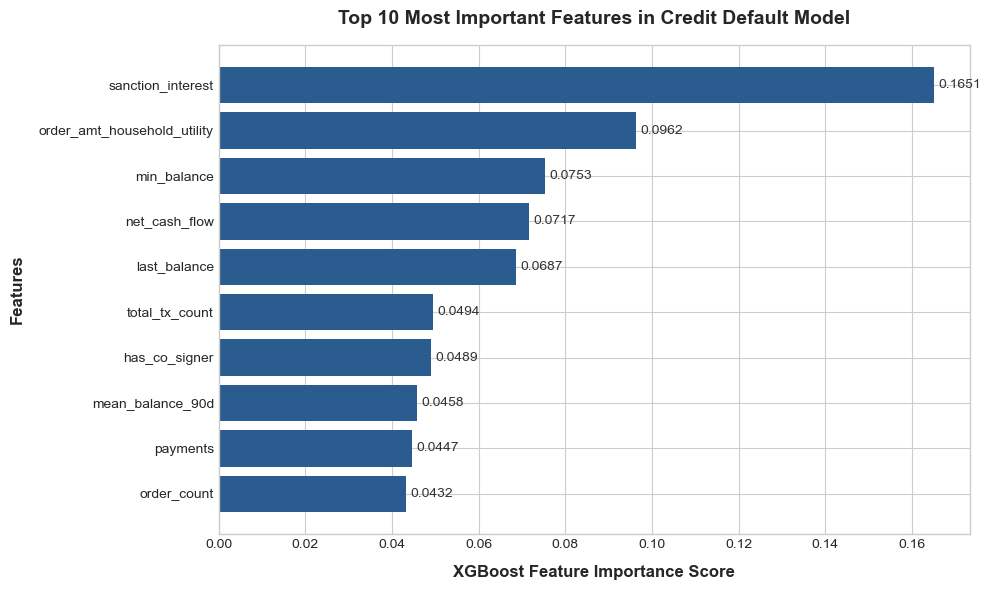

In [9]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seaborn_plt

# Define paths
data_dir = '../'
model_path = os.path.join(data_dir, 'model/credit_default_xgboost_model.pkl') # Update filename if yours differs
matrix_path = os.path.join(data_dir, 'modelData/master_modeling_matrix.csv')

# Load the saved artifact dictionary and extract the model
saved_bundle = joblib.load(model_path)
model = saved_bundle.get('model') or saved_bundle.get('classifier') or saved_bundle.get('xgb_model')

# Extract feature names directly from the trained model object or dataset
if hasattr(model, 'feature_names_in_'):
    feature_names = model.feature_names_in_
else:
    master_df = pd.read_csv(matrix_path, index_col='loan_id')
    feature_names = master_df.drop(columns=['target']).columns

# Create a DataFrame of feature importances and get the top 10
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)  # Ascending so top 10 appears at the top when plotted

top_10 = importance_df.tail(10)  # Last 10 since sorted ascending

# Set up the visualization style
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Create horizontal bar chart
bars = plt.barh(top_10['Feature'], top_10['Importance'], color='#2b5c8f', edgecolor='none')

# Add labels and title
plt.xlabel('XGBoost Feature Importance Score', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Features', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Top 10 Most Important Features in Credit Default Model', fontsize=14, fontweight='bold', pad=15)

# Add value labels on the bars for clarity
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center', ha='left', fontsize=10, color='#333333')

plt.tight_layout()

# Save the figure as an image file
# output_graph_path = os.path.join(data_dir, 'top_10_feature_importances.png')
# plt.savefig(output_graph_path, dpi=300)
# print(f"Graph successfully saved to: {output_graph_path}")

# Display the plot window
plt.show()

Computing valid learning curves...
Learning curves graph successfully saved to: ../learning_curves.png


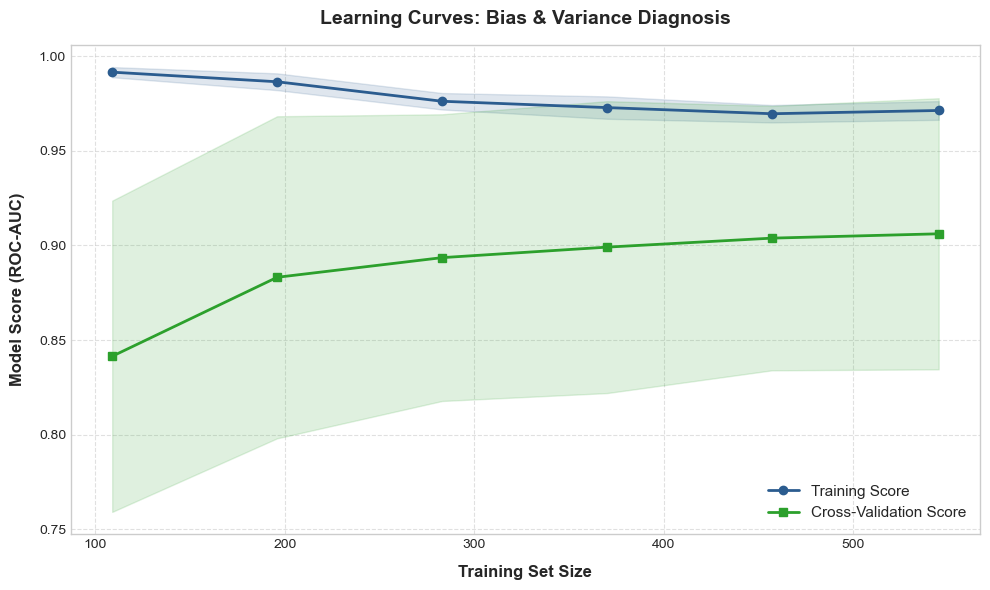

In [10]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import xgboost as xgb

# ==========================================
# 1. LOAD DATA AND MODEL INFO
# ==========================================
data_dir = '../'
matrix_path = os.path.join(data_dir, 'modelData/master_modeling_matrix.csv')
model_path = os.path.join(data_dir, 'model/credit_default_xgboost_model.pkl')

# Load dataset and split features/target
master_df = pd.read_csv(matrix_path, index_col='loan_id')

# Drop target and any lingering non-numeric date columns (like 'loan_date')
X = master_df.drop(columns=['target'])
if 'loan_date' in X.columns:
    X = X.drop(columns=['loan_date'])

# Ensure all columns are numeric type
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = master_df['target']

# Load the saved model bundle to grab its parameters
saved_bundle = joblib.load(model_path)
trained_model = saved_bundle.get('model') or saved_bundle.get('classifier') or saved_bundle.get('xgb_model')

params = trained_model.get_params() if hasattr(trained_model, 'get_params') else {}
fresh_model = xgb.XGBClassifier(**params)

print("Computing valid learning curves...")

# ==========================================
# 2. GENERATE LEARNING CURVES
# ==========================================
train_sizes, train_scores, val_scores = learning_curve(
    estimator=fresh_model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.2, 1.0, 6), # Evaluates from 20% to 100% of data
    cv=5,                                  # 5-fold cross-validation
    scoring='roc_auc',                     # Metric used to gauge performance
    n_jobs=-1                              
)

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# ==========================================
# 3. PLOT LEARNING CURVES
# ==========================================
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Plot training performance
plt.plot(train_sizes, train_mean, label='Training Score', color='#2b5c8f', marker='o', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='#2b5c8f', alpha=0.15)

# Plot validation performance
plt.plot(train_sizes, val_mean, label='Cross-Validation Score', color='#2ca02c', marker='s', linewidth=2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color='#2ca02c', alpha=0.15)

# Formatting layout
plt.title('Learning Curves: Bias & Variance Diagnosis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Set Size', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Model Score (ROC-AUC)', fontsize=12, fontweight='bold', labelpad=10)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save figure
output_path = os.path.join(data_dir, 'learning_curves.png')
plt.savefig(output_path, dpi=300)
print(f"Learning curves graph successfully saved to: {output_path}")

plt.show()